# Parity Plots

This notebook generates parity plots for comparing the different methods (GPR, hybrid GPR, learned equation) across all of the folds.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as mse
import GPy
import shap
import pickle
import functools
from IPython.display import display
from IPython.display import Image
from matplotlib.pyplot import figure
import json
import lzma

 /Users/dja3/envir/ii/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
df = pd.read_csv("data/disp_dataset.csv")
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values * (-1)

# All folds

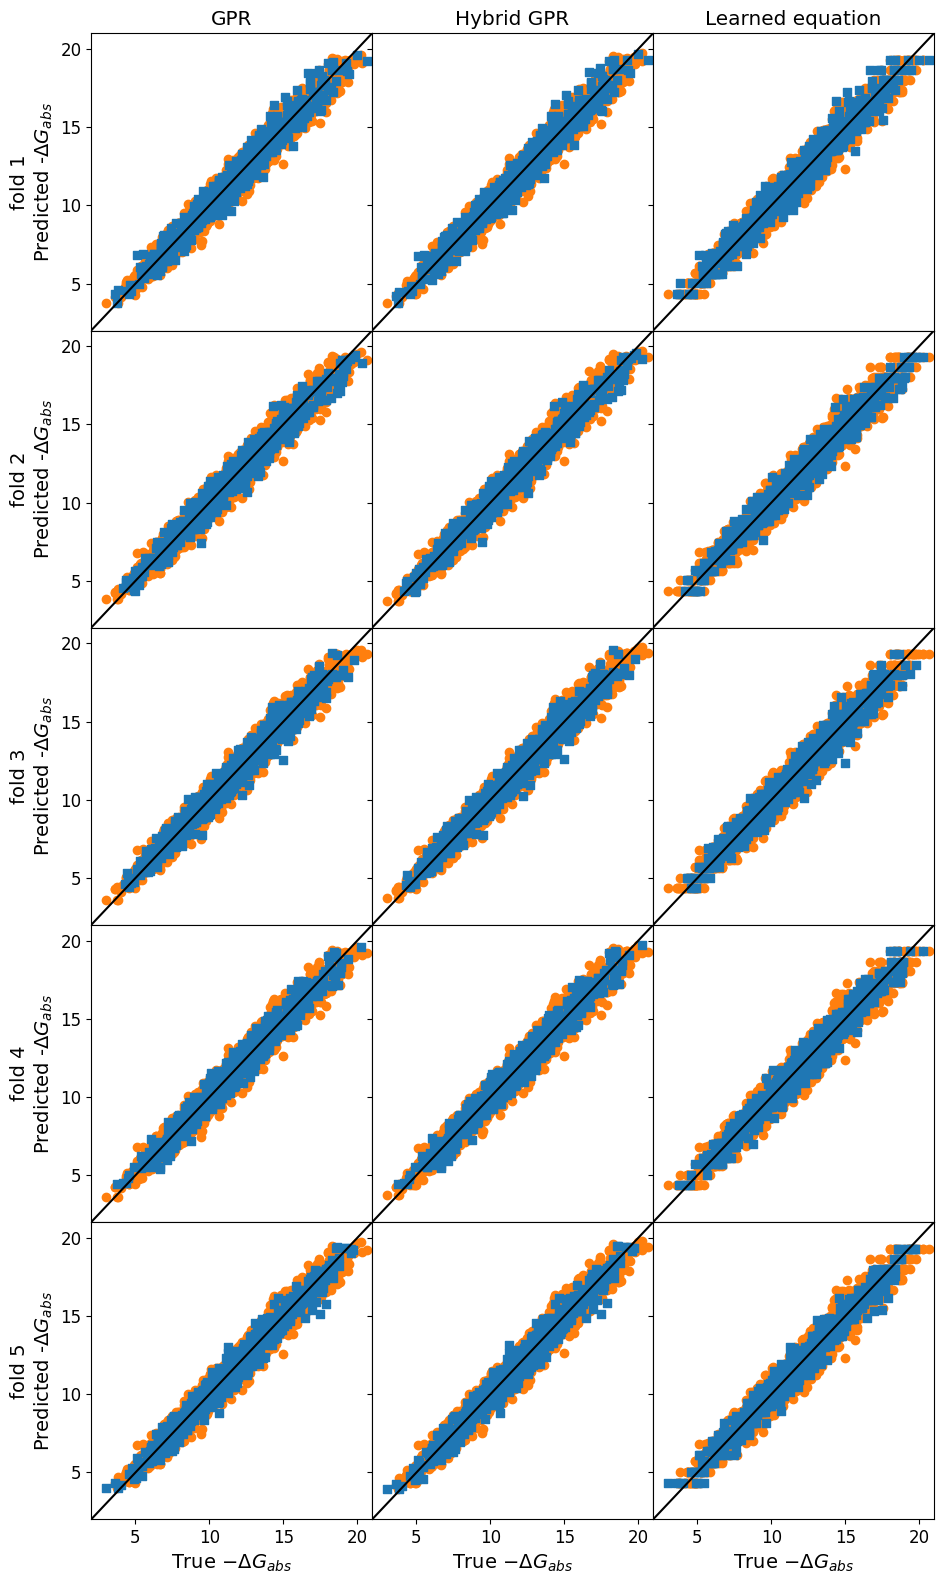

In [4]:
fig = plt.figure(figsize=(8 / 5 * 3.0 * 2, 8 * 2))
gs = fig.add_gridspec(5, 3, hspace=0, wspace=0)
ax = gs.subplots(sharex="col", sharey="row")

# GPR only
for i in range(5):

    # Load model and test/train split
    with lzma.open("models/ard_fold" + str(i) + ".pkl.xz", "rb") as file:
        m = pickle.load(file)
    train_mask = np.genfromtxt(
        "data/data_split.csv", delimiter=",", skip_header=1, dtype=bool, usecols=i
    )

    # Gather results
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X[train_mask, :])
    X_test = scaler.transform(X[np.logical_not(train_mask), :])
    yp_train, _ = m.predict(X_train)
    yp_test, _ = m.predict(X_test)
    y_train = y[train_mask]
    y_test = y[np.logical_not(train_mask)]

    # Parity plot
    ax[i][0].scatter(y_train, yp_train, c="tab:orange")
    ax[i][0].scatter(y_test, yp_test, marker="s", c="tab:blue")
    ax[i][0].plot([2, 21], [2, 21], linestyle="solid", c="k")

for i in range(5):

    # Load model and test/train split
    with lzma.open("hybridmodels/ard_prior_fold" + str(i) + ".pkl.xz", "rb") as file:
        m = pickle.load(file)
    train_mask = np.genfromtxt(
        "data/data_split.csv", delimiter=",", skip_header=1, dtype=bool, usecols=i
    )

    # Get data
    scaler = StandardScaler()
    X_train = X[train_mask, :]
    X_test = X[np.logical_not(train_mask), :]
    y_train = y[train_mask]
    y_test = y[np.logical_not(train_mask)]

    X_train_scal = scaler.fit_transform(X_train)
    X_test_scal = scaler.transform(X_test)

    # Get data for input to prior
    mask = np.zeros(len(df.columns) - 1).astype(bool)
    mask[8:12] = True
    mask[9] = False
    X_train_prior = np.multiply(
        X[train_mask, :][:, mask], X[train_mask, 13][:, np.newaxis]
    )
    X_test_prior = np.multiply(
        X[np.logical_not(train_mask), :][:, mask],
        X[np.logical_not(train_mask), 13][:, np.newaxis],
    )

    # Get prior
    with open("hybridmodels/ard_linregprior" + "_fold" + str(0) + ".json", "r") as file:
        linreg = json.load(file)
    coef = np.array(linreg["coef"])
    intercept = linreg["intercept"]

    yprior_train = np.sum(X_train_prior * coef, axis=1) + intercept
    yprior_test = np.sum(X_test_prior * coef, axis=1) + intercept

    # Get predictions
    yp_train, _ = m.predict(X_train_scal)
    yp_test, _ = m.predict(X_test_scal)

    yp_train += yprior_train.reshape(-1, 1)
    yp_test += yprior_test.reshape(-1, 1)

    # Parity plot
    ax[i][1].scatter(y_train, yp_train, c="tab:orange")
    ax[i][1].scatter(y_test, yp_test, marker="s", c="tab:blue")
    ax[i][1].plot([2, 21], [2, 21], linestyle="solid", c="k")

    ax[i][2].scatter(y_train, yprior_train.reshape(-1, 1), c="tab:orange")
    ax[i][2].scatter(y_test, yprior_test.reshape(-1, 1), marker="s", c="tab:blue")
    ax[i][2].plot([2, 21], [2, 21], linestyle="solid", c="k")


for i in range(5):

    # ax[i][0].set_title('fold '+str(i+1))
    ax[i][0].set_ylabel("fold " + str(i + 1) + "\n" + r"Predicted -$\Delta G_{abs}$")

    for j in range(3):

        ax[i][j].set_xlim(2, 21)
        ax[i][j].set_ylim(2, 21)
        ax[i][j].set_xticks(np.arange(5, 25, 5))
        ax[i][j].set_yticks(np.arange(5, 25, 5))

        ax[4][j].set_xlabel(r"True $-\Delta G_{abs}$")

ax[0][0].set_title("GPR")
ax[0][1].set_title("Hybrid GPR")
ax[0][2].set_title("Learned equation")


plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14

plt.tight_layout()
plt.savefig("figures/disp_parity.jpg", dpi=600)

# Single fold

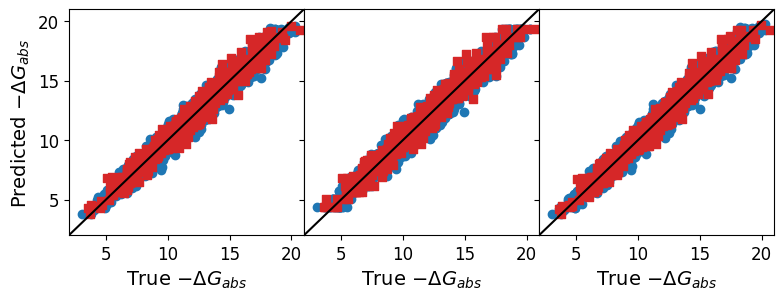

In [5]:
fig = plt.figure(figsize=(8, 8 / 3 + 0.5))
gs = fig.add_gridspec(1, 3, hspace=0, wspace=0)
ax = gs.subplots(sharex="col", sharey="row")

# GPR only
for i in range(1):

    # Load model and test/train split
    with lzma.open("models/ard_fold" + str(i) + ".pkl.xz", "rb") as file:
        m = pickle.load(file)
    train_mask = np.genfromtxt(
        "data/data_split.csv", delimiter=",", skip_header=1, dtype=bool, usecols=i
    )

    # Gather results
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X[train_mask, :])
    X_test = scaler.transform(X[np.logical_not(train_mask), :])
    yp_train, _ = m.predict(X_train)
    yp_test, _ = m.predict(X_test)
    y_train = y[train_mask]
    y_test = y[np.logical_not(train_mask)]

    # Parity plot
    ax[i].scatter(y_train, yp_train)
    ax[i].scatter(y_test, yp_test, marker="s", c="tab:red")
    ax[i].plot([2, 21], [2, 21], linestyle="solid", c="k")

for i in range(1):

    # Load model and test/train split
    with lzma.open("hybridmodels/ard_prior_fold" + str(i) + ".pkl.xz", "rb") as file:
        m = pickle.load(file)
    train_mask = np.genfromtxt(
        "data/data_split.csv", delimiter=",", skip_header=1, dtype=bool, usecols=i
    )

    # Get data
    scaler = StandardScaler()
    X_train = X[train_mask, :]
    X_test = X[np.logical_not(train_mask), :]
    y_train = y[train_mask]
    y_test = y[np.logical_not(train_mask)]

    X_train_scal = scaler.fit_transform(X_train)
    X_test_scal = scaler.transform(X_test)

    # Get data for input to prior
    mask = np.zeros(len(df.columns) - 1).astype(bool)
    mask[8:12] = True
    mask[9] = False
    X_train_prior = np.multiply(
        X[train_mask, :][:, mask], X[train_mask, 13][:, np.newaxis]
    )
    X_test_prior = np.multiply(
        X[np.logical_not(train_mask), :][:, mask],
        X[np.logical_not(train_mask), 13][:, np.newaxis],
    )

    # Get prior
    with open("hybridmodels/ard_linregprior" + "_fold" + str(0) + ".json", "r") as file:
        linreg = json.load(file)
    coef = np.array(linreg["coef"])
    intercept = linreg["intercept"]

    yprior_train = np.sum(X_train_prior * coef, axis=1) + intercept
    yprior_test = np.sum(X_test_prior * coef, axis=1) + intercept

    # Get predictions
    yp_train, _ = m.predict(X_train_scal)
    yp_test, _ = m.predict(X_test_scal)

    yp_train += yprior_train.reshape(-1, 1)
    yp_test += yprior_test.reshape(-1, 1)

    # Parity plot
    ax[2].scatter(y_train, yp_train)
    ax[2].scatter(y_test, yp_test, marker="s", c="tab:red")
    ax[2].plot([2, 21], [2, 21], linestyle="solid", c="k")

    ax[1].scatter(y_train, yprior_train.reshape(-1, 1))
    ax[1].scatter(y_test, yprior_test.reshape(-1, 1), marker="s", c="tab:red")
    ax[1].plot([2, 21], [2, 21], linestyle="solid", c="k")


for j in range(3):
    ax[j].set_xlim(2, 21)
    ax[j].set_ylim(2, 21)
    ax[j].set_xticks(np.arange(5, 25, 5))
    ax[j].set_yticks(np.arange(5, 25, 5))

    ax[j].set_xlabel(r"True $-\Delta G_{abs}$")

ax[0].set_ylabel(r"Predicted $-\Delta G_{abs}$")
# ax[1][0].set_ylabel('GPR with prior\n'+r'Predicted $\Delta G_{abs}$')
# ax[2][0].set_ylabel('Learned equation\n'+r'Predicted $\Delta G_{abs}$')

# ax[0].set_title('fold '+str(i+1))

plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14

plt.tight_layout()
plt.savefig("figures/disp_parity_3panel.jpg", dpi=600)